# Fragility Curve for a Sheet Pile Wall — Corrosion

## Introduction

This notebook builds a **fragility curve** for a cantilever sheet pile wall as a function of a **corrosion rate** parameter. The fragility curve describes the conditional probability of failure for a given corrosion level:

$$r \;\rightarrow\; P\!\left(g \leq 0 \;\middle|\; r\right)$$

The corrosion rate $r$ is a dimensionless factor between **0** (no corrosion) and **1** (fully corroded). Both the elastic stiffness and the moment capacity of the sheet pile section degrade **linearly** with $r$:

$$EI(r) = EI_0 \cdot (1 - r)$$

$$M_{\text{capacity}}(r) = M_{\text{capacity},0} \cdot (1 - r)$$

The reduced EI is applied directly in the D-SheetPiling model (affecting the computed moment distribution), while the reduced $M_{\text{capacity}}$ enters the limit state check.

For each value of $r$ the remaining stochastic variables (`phi_sand`, `su_clay`, `phreatic_level`) are kept uncertain and a **FORM** analysis is run. The result is a curve of $P_f$ vs $r$.

### D-SheetPiling model

The base model is the same cantilever sheet pile wall from the [DSheetPiling Tutorial](DSheetPiling_Tutorial.ipynb): a canal retaining wall in a two-layer soil profile (Sand over Clay) with a canal bed at −5.0 m NAP and a water level difference between the retained side and the canal side.

In [1]:
from geolib.models.dsheetpiling import DSheetPilingModel
from geolib.models.dsheetpiling.constructions import Sheet, SheetPileProperties
from geolib.models.dsheetpiling.dsheetpiling_model import SheetModelType
from geolib.models.dsheetpiling.profiles import SoilProfile, SoilLayer
from geolib.models.dsheetpiling.settings import (
    LateralEarthPressureMethod,
    LateralEarthPressureMethodStage,
    Side,
    PassiveSide,
)
from geolib.models.dsheetpiling.water_level import WaterLevel
from geolib.models.dsheetpiling.surface import Surface
from geolib.geometry.one import Point
from geolib.soils import Soil

from probabilistic_library import (
    ReliabilityProject,
    DistributionType,
    ReliabilityMethod,
    FragilityCurve,
    FragilityValue,
    StandardNormal,
)

import copy
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tempfile

## Step 1 — Build the D-SheetPiling base model

The base model represents a cantilever sheet pile wall along a canal. The retained side (left) has ground level at 0.0 m NAP with a phreatic level at −1.0 m NAP. The canal side (right) has its bed at −5.0 m NAP with a canal water level at −2.0 m NAP.

This is identical to the tutorial notebook. See [DSheetPiling_Tutorial.ipynb](DSheetPiling_Tutorial.ipynb) for a detailed explanation of each step.

In [2]:
# --- Model ---
base_model = DSheetPilingModel()

console_path = Path(r"C:\Program Files (x86)\Deltares\D-Sheet Piling 24.1.1\DSheetPiling.exe")
base_model.set_meta_property("dsheetpiling_console_path", console_path)

base_model.set_model(SheetModelType(method=LateralEarthPressureMethod.C_PHI_DELTA))
base_model.datastructure.input_data.model.check_vertical_balance = False

# --- Soils ---
sand = Soil(name="Sand")
sand.soil_weight_parameters.saturated_weight = 20.0
sand.soil_weight_parameters.unsaturated_weight = 17.0
sand.mohr_coulomb_parameters.friction_angle = 30.0
sand.mohr_coulomb_parameters.cohesion = 0.0
sand.mohr_coulomb_parameters.friction_angle_interface = 20.0
base_model.add_soil(sand)

clay = Soil(name="Clay")
clay.soil_weight_parameters.saturated_weight = 18.0
clay.soil_weight_parameters.unsaturated_weight = 16.0
clay.mohr_coulomb_parameters.friction_angle = 0.0
clay.mohr_coulomb_parameters.cohesion = 25.0
clay.mohr_coulomb_parameters.friction_angle_interface = 0.0
base_model.add_soil(clay)

# --- Sheet pile ---
sheet = Sheet(
    name="AZ 26",
    sheet_pile_properties=SheetPileProperties(
        elastic_stiffness_ei=50000,
        section_bottom_level=-35.0,
        mr_char_el=500.0,
    ),
)
base_model.set_construction(top_level=0.0, elements=[sheet])

# --- Construction stage ---
stage_id = base_model.add_stage(
    name="Canal",
    passive_side=PassiveSide.DSHEETPILING_DETERMINED,
    method_left=LateralEarthPressureMethodStage.C_PHI_DELTA,
    method_right=LateralEarthPressureMethodStage.C_PHI_DELTA,
)

bottom_depth = -5.0

# Left side (retained)
surface_left = Surface(name="Surface_left", points=[Point(x=0.0, z=0.0)])
base_model.add_surface(surface_left, side=Side.LEFT, stage_id=stage_id)

profile_left = SoilProfile(
    name="Left",
    layers=[
        SoilLayer(top_of_layer=0.0, soil="Sand"),
        SoilLayer(top_of_layer=-5.0, soil="Clay"),
    ],
    coordinate=Point(x=0.0),
)
base_model.add_profile(profile_left, side=Side.LEFT, stage_id=stage_id)

wl_left = WaterLevel(name="WL_left", level=-1.0)
base_model.add_head_line(wl_left, side=Side.LEFT, stage_id=stage_id)

# Right side (canal)
surface_right = Surface(name="Surface_right", points=[Point(x=0.0, z=bottom_depth)])
base_model.add_surface(surface_right, side=Side.RIGHT, stage_id=stage_id)

profile_right = SoilProfile(
    name="Right",
    layers=[
        SoilLayer(top_of_layer=bottom_depth, soil="Clay"),
    ],
    coordinate=Point(x=0.0, z=bottom_depth),
)
base_model.add_profile(profile_right, side=Side.RIGHT, stage_id=stage_id)

# Canal water level
wl_right = WaterLevel(name="WL_right", level=-2.0)
base_model.add_head_line(wl_right, side=Side.RIGHT, stage_id=stage_id)

## Step 2 — Define the limit state function with corrosion

The limit state function includes a fourth parameter, `corrosion_rate` ($r \in [0, 1]$), which controls the degradation of both the stiffness and the moment capacity of the sheet pile section. Canal walls are particularly susceptible to corrosion due to permanent water contact on the canal side and cyclic wetting on the retained side.

| Parameter | Symbol | Intact value | Corroded value |
|-----------|--------|-------------|----------------|
| Elastic stiffness | $EI$ | 50 000 kNm²/m | $EI_0 \cdot (1 - r)$ |
| Moment capacity | $M_{\text{capacity}}$ | 500 kNm/m | $M_{\text{capacity},0} \cdot (1 - r)$ |

The reduced $EI$ is written into the D-SheetPiling model so that D-SheetPiling computes the correct structural response for the degraded section. The reduced $M_{\text{capacity}}$ is used in the limit state check.

During the fragility curve calculation, `corrosion_rate` is set to a **deterministic** value at each step.

In [3]:
# Intact section properties
EI_0 = 50_000.0       # elastic stiffness [kNm²/m]
M_CAPACITY_0 = 500.0   # moment capacity [kNm/m]

# Working directory for temporary .shi files
WORK_DIR = Path(tempfile.mkdtemp(prefix="dsheet_fc_")).resolve()


def lsf_sheetpile(phi_sand, su_clay, phreatic_level, corrosion_rate):
    """
    Limit state function: g = M_capacity(r) - |M_max|

    Parameters
    ----------
    phi_sand : float
        Friction angle of the sand layer [deg].
    su_clay : float
        Undrained shear strength of the clay layer [kPa].
    phreatic_level : float
        Phreatic level behind the wall (retained side) [m NAP].
    corrosion_rate : float
        Corrosion rate [-], between 0 (intact) and 1 (fully corroded).
    """
    if corrosion_rate >= 0.95:
        return -9999

    # Degraded section properties
    factor = 1.0 - corrosion_rate
    m_capacity = M_CAPACITY_0 * factor
    ei = EI_0 * factor

    # Deep-copy and update the base model
    model = copy.deepcopy(base_model)

    # Add a safeguard against too low strength values
    if phi_sand <= 5.0 or su_clay <= 5.0:
        return 0

    # Update soil parameters
    soils = model.datastructure.input_data.soil_collection.soil
    soils[0].soilphi = phi_sand
    soils[0].soildelta = 2 / 3 * phi_sand
    soils[1].soilcohesion = su_clay

    # Update phreatic level
    model.datastructure.input_data.waterlevels.levels[0].level = phreatic_level

    # Update sheet pile stiffness
    model.datastructure.input_data.sheet_piling.sheetpiling[0].sheetpilingelementei = ei

    # Serialize and execute
    shi_path = WORK_DIR / "temp_model.shi"
    model.serialize(shi_path)
    model.execute()

    # Extract maximum bending moment
    stage_output = model.output.construction_stage[0]
    mfd = stage_output.moments_forces_displacements.momentsforcesdisplacements
    max_moment = max(abs(row["moment"]) for row in mfd)

    return m_capacity - max_moment

## Step 3 — Set up the project and stochastic variables

We create a `ReliabilityProject` with the four-argument limit state function. The first three variables are stochastic; `corrosion_rate` is initially set to a dummy deterministic value — it will be overwritten in the fragility curve loop.

In [4]:
project = ReliabilityProject()
project.model = lsf_sheetpile

# Stochastic variables
project.variables["phi_sand"].distribution = DistributionType.normal
project.variables["phi_sand"].mean = 25.0
project.variables["phi_sand"].variation = 0.10

project.variables["su_clay"].distribution = DistributionType.log_normal
project.variables["su_clay"].mean = 20.0
project.variables["su_clay"].variation = 0.10

project.variables["phreatic_level"].distribution = DistributionType.uniform
project.variables["phreatic_level"].minimum = -4.0
project.variables["phreatic_level"].maximum = -2.0

# Corrosion rate — deterministic placeholder (overwritten in the loop)
project.variables["corrosion_rate"].distribution = DistributionType.deterministic
project.variables["corrosion_rate"].mean = 0.0

# FORM settings
project.settings.reliability_method = ReliabilityMethod.form
project.settings.maximum_iterations = 20
project.settings.relaxation_factor = 0.15
project.settings.variation_coefficient = 0.05
project.settings.step_size = 0.05

## Step 4 — Build the fragility curve (with caching)

The FORM loop over corrosion rate values is the most expensive step in this notebook. To avoid re-running it every time, the results are **cached to a JSON file**. On subsequent runs the cache is loaded automatically.

Set `FORCE_RECOMPUTE = True` to discard the cache and re-run all FORM analyses.

In [5]:
from scipy.stats import norm

CACHE_FILE = Path("fragility_cache.json")
FORCE_RECOMPUTE = False

corrosion_rates = np.append(np.arange(0.0, 1.0, 0.2), 1.0)

if not FORCE_RECOMPUTE and CACHE_FILE.exists():
    # ---- Load from cache ----
    with open(CACHE_FILE) as f:
        cache = json.load(f)
    corrosion_rates = np.array(cache["corrosion_rates"])
    fc_beta = cache["fc_beta"]
    fc_pf = cache["fc_pf"]
    print(f"Loaded {len(fc_beta)} fragility curve points from {CACHE_FILE}")

    # Rebuild the FragilityCurve object from cached values
    fragility_curve = FragilityCurve()
    fragility_curve.name = "corrosion"
    for r, b in zip(corrosion_rates, fc_beta):
        fv = FragilityValue()
        fv.x = float(r)

        # Clip pf to avoid extreme values
        pf = norm.cdf(-b)
        pf = max(pf, 1e-5)
        pf = min(pf, 1-1e-5)
        b = norm.ppf(1-pf)

        fv.reliability_index = b
        fragility_curve.fragility_values.append(fv)

else:
    # ---- Compute and save ----
    fragility_curve = FragilityCurve()
    fragility_curve.name = "corrosion"

    fc_beta = []
    fc_pf = []

    for r in corrosion_rates:
        print(f"Running FORM for corrosion rate = {r:.2f} ...")

        project.variables["corrosion_rate"].mean = float(r)
        project.run()

        dp = project.design_point

        fv = FragilityValue()
        fv.x = float(r)

        # Clip pf to avoid extreme values
        pf = norm.cdf(-dp.reliability_index)
        pf = max(pf, 1e-5)
        pf = min(pf, 1-1e-5)
        b = norm.ppf(1-pf)

        fv.reliability_index = b
        fv.design_point = dp
        fragility_curve.fragility_values.append(fv)

        fc_beta.append(b)
        fc_pf.append(pf)

        print(f"  β = {b:.3f},  Pf = {pf:.4e}")

    # Save cache
    cache = {
        "corrosion_rates": corrosion_rates.tolist(),
        "fc_beta": fc_beta,
        "fc_pf": fc_pf,
    }
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)
    print(f"\nDone. Results saved to {CACHE_FILE}")

Loaded 6 fragility curve points from fragility_cache.json


## Step 5 — Plot the fragility curve

### 5.1 — Probability of failure vs corrosion rate

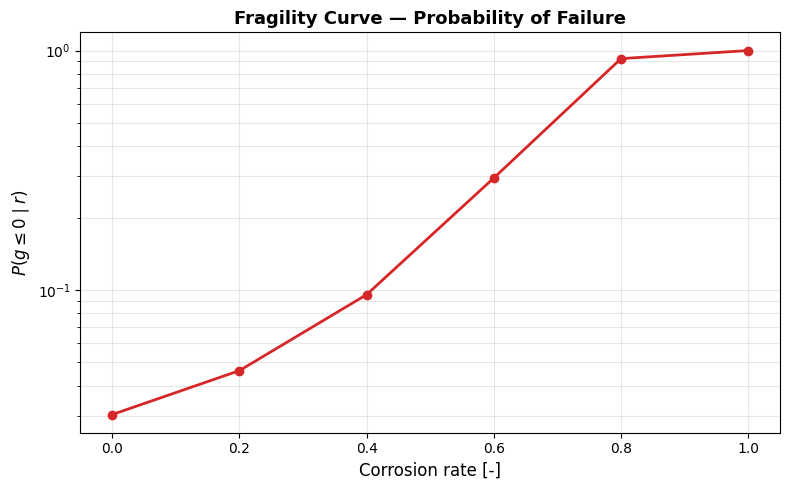

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(corrosion_rates, fc_pf, "o-", color="tab:red", linewidth=2, markersize=6)
ax.set_xlabel("Corrosion rate [-]", fontsize=12)
ax.set_ylabel(r"$P(g \leq 0 \mid r)$", fontsize=12)
ax.set_title("Fragility Curve — Probability of Failure", fontweight="bold", fontsize=13)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

### 5.2 — Reliability index vs corrosion rate

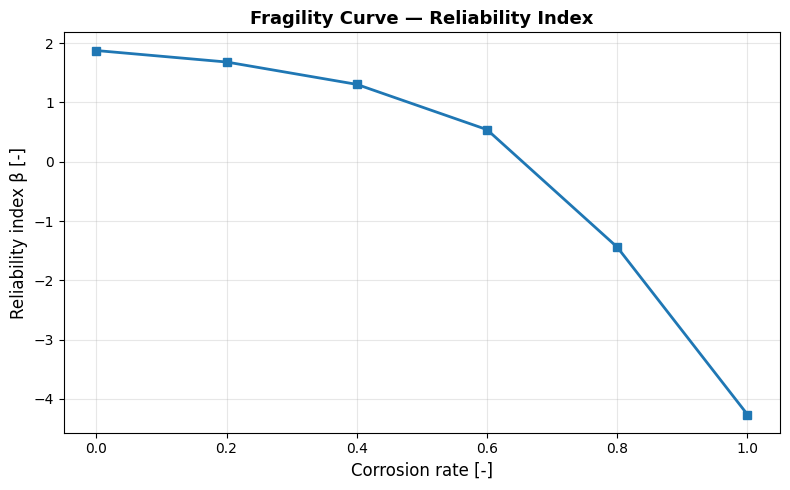

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(corrosion_rates, fc_beta, "s-", color="tab:blue", linewidth=2, markersize=6)
ax.set_xlabel("Corrosion rate [-]", fontsize=12)
ax.set_ylabel("Reliability index β [-]", fontsize=12)
ax.set_title("Fragility Curve — Reliability Index", fontweight="bold", fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 5.3 — Section property degradation

For reference, the plot below shows how the elastic stiffness and moment capacity degrade linearly with the corrosion rate.

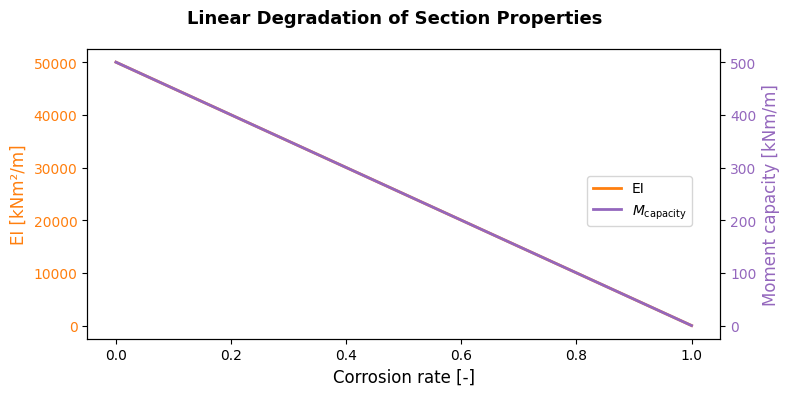

In [8]:
r_fine = np.linspace(0.0, 1.0, 200)

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(r_fine, EI_0 * (1 - r_fine), color="tab:orange", linewidth=2, label="EI")
ax1.set_xlabel("Corrosion rate [-]", fontsize=12)
ax1.set_ylabel("EI [kNm²/m]", color="tab:orange", fontsize=12)
ax1.tick_params(axis="y", labelcolor="tab:orange")

ax2 = ax1.twinx()
ax2.plot(r_fine, M_CAPACITY_0 * (1 - r_fine), color="tab:purple", linewidth=2, label=r"$M_{\mathrm{capacity}}$")
ax2.set_ylabel("Moment capacity [kNm/m]", color="tab:purple", fontsize=12)
ax2.tick_params(axis="y", labelcolor="tab:purple")

fig.suptitle("Linear Degradation of Section Properties", fontweight="bold", fontsize=13)
fig.legend(loc="center right", bbox_to_anchor=(0.88, 0.5))
fig.tight_layout()
plt.show()

## Step 6 — Summary table

In [9]:
print(f"{'Corrosion rate':>16} {'EI':>12} {'M_capacity':>12} {'β':>8} {'Pf':>14}")
print(f"{'[-]':>16} {'[kNm²/m]':>12} {'[kNm/m]':>12} {'[-]':>8} {'[-]':>14}")
print("-" * 66)
for r, b, p in zip(corrosion_rates, fc_beta, fc_pf):
    factor = 1.0 - r
    print(f"{r:>16.2f} {EI_0 * factor:>12.0f} {M_CAPACITY_0 * factor:>12.1f} {b:>8.3f} {p:>14.4e}")

  Corrosion rate           EI   M_capacity        β             Pf
             [-]     [kNm²/m]      [kNm/m]      [-]            [-]
------------------------------------------------------------------
            0.00        50000        500.0    1.876     3.0303e-02
            0.20        40000        400.0    1.683     4.6209e-02
            0.40        30000        300.0    1.305     9.5878e-02
            0.60        20000        200.0    0.542     2.9397e-01
            0.80        10000        100.0   -1.441     9.2519e-01
            1.00            0          0.0   -4.265     9.9999e-01


## Interpretation of the fragility curve

The fragility curve shows how the failure probability increases as the corrosion rate rises from 0 (intact) to 1 (fully corroded):

- At **low corrosion rates** (r < 0.2), the section retains most of its stiffness and capacity. The failure probability is governed mainly by the soil and water level uncertainty.
- At **intermediate corrosion rates** (r ≈ 0.3–0.6), the capacity reduction becomes comparable to the loading, and $P_f$ increases steeply. This is the transition zone where inspection and maintenance decisions have the largest impact.
- At **high corrosion rates** (r > 0.7), the remaining capacity is small and failure becomes almost certain regardless of the soil conditions.

Note that reducing the stiffness $EI$ also affects the computed bending moments: a more flexible wall redistributes earth pressures differently, which may partially offset the capacity loss at moderate corrosion levels.

In the next step, we integrate this fragility curve with a **time-dependent corrosion model** to obtain the failure probability as a function of time. This is especially relevant for canal walls, where the corrosion environment is determined by the water chemistry and the exposure conditions along the waterway.

## Step 7 — Time-dependent failure probability

### Corrosion models

The corrosion ratio $r$ evolves over the structure's lifetime. At each time $t$, it follows a **Beta distribution** on $[0,\,1]$ whose **mode** grows according to an exponential law:

$$\text{mode}(t) = 1 - e^{-\lambda\, t}$$

We compare two environments relevant for canal sheet pile walls:

| Scenario | $\lambda$ | mode at 25 yr | mode at 50 yr | Physical setting |
|----------|-----------|---------------|---------------|------------------|
| **Normal** | 0.060 /yr | 0.78 | 0.95 | Fresh-water canal, neutral soil |
| **Aggressive** | 0.120 /yr | 0.95 | 0.998 | Brackish canal, acidic or saline soil |

The Beta distribution is parameterised via a concentration $\kappa = \alpha + \beta = 10$:

$$\alpha(t) = m(t)\,(\kappa - 2) + 1, \qquad \beta(t) = \bigl(1 - m(t)\bigr)\,(\kappa - 2) + 1$$

For each time step and each model, we integrate the fragility curve with the corrosion distribution:

$$P_f(t) = \int_0^1 P(g \leq 0 \mid r)\;\,f_r(r;\,t)\;\mathrm{d}r$$

In [10]:
from probabilistic_library import Stochast

# Common parameters
DESIGN_LIFE = 50.0   # years
R_STAR = 0.95        # target mode at the scenario's characteristic time
KAPPA = 10.0         # concentration (α + β)

# Two corrosion scenarios
models = {
    "Normal":     -np.log(1 - R_STAR) / 50.0,   # λ ≈ 0.060 /yr
    "Aggressive": -np.log(1 - R_STAR) / 25.0,    # λ ≈ 0.120 /yr
}


def beta_params_at(t, lam):
    """Return (alpha, beta) for a Beta-distributed corrosion rate at time t."""
    mode = 1.0 - np.exp(-lam * t)
    mode = np.clip(mode, 1e-6, 1 - 1e-6)
    a = mode * (KAPPA - 2) + 1
    b = (1 - mode) * (KAPPA - 2) + 1
    return a, b


print("Defined corrosion models:")
for name, lam in models.items():
    print(f"  {name:<12s}  λ = {lam:.4f} /yr")

Defined corrosion models:
  Normal        λ = 0.0599 /yr
  Aggressive    λ = 0.1198 /yr


### Visualise the corrosion models

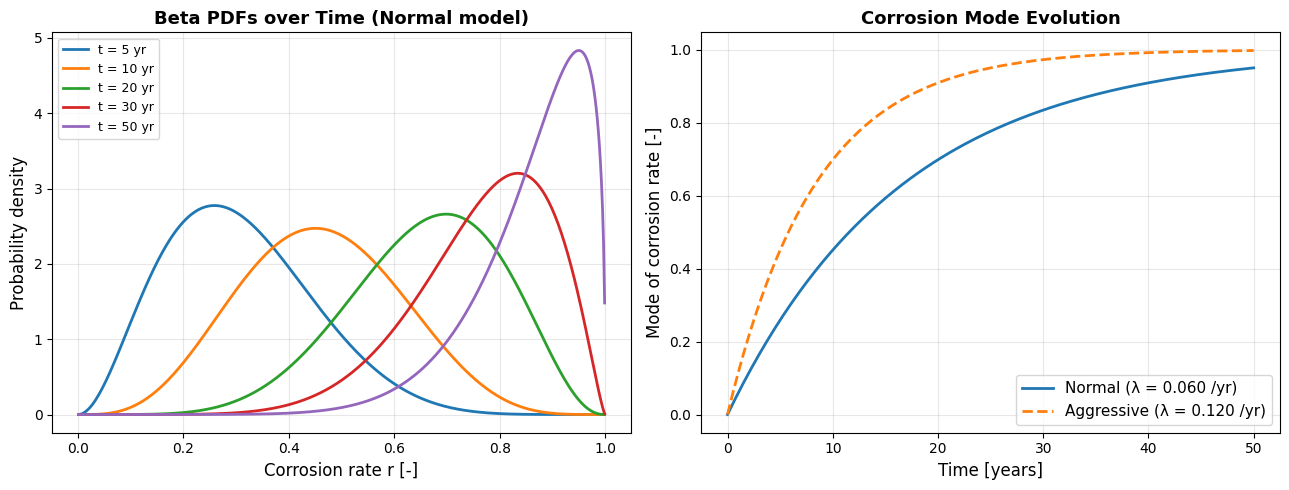

In [11]:
from scipy.stats import beta as beta_dist

r_pdf = np.linspace(0.001, 0.999, 500)
t_arr = np.linspace(0, DESIGN_LIFE, 200)
times_to_show = [5, 10, 20, 30, 50]
model_colors = {"Normal": "tab:blue", "Aggressive": "tab:orange"}
model_styles = {"Normal": "-", "Aggressive": "--"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Beta PDFs at selected times (Normal model)
ax = axes[0]
for t in times_to_show:
    a, b = beta_params_at(t, models["Normal"])
    ax.plot(r_pdf, beta_dist.pdf(r_pdf, a, b), linewidth=2, label=f"t = {t} yr")
ax.set_xlabel("Corrosion rate r [-]", fontsize=12)
ax.set_ylabel("Probability density", fontsize=12)
ax.set_title("Beta PDFs over Time (Normal model)", fontweight="bold", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: mode evolution for both models
ax = axes[1]
for name, lam in models.items():
    ax.plot(t_arr, 1 - np.exp(-lam * t_arr), linewidth=2,
            color=model_colors[name], linestyle=model_styles[name],
            label=f"{name} (λ = {lam:.3f} /yr)")
ax.set_xlabel("Time [years]", fontsize=12)
ax.set_ylabel("Mode of corrosion rate [-]", fontsize=12)
ax.set_title("Corrosion Mode Evolution", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Integrate the fragility curve over a time grid

For each year on the time grid and each corrosion model, we create a Beta-distributed `Stochast` and integrate against the fragility curve to obtain $\beta(t)$ and $P_f(t)$.

In [12]:
# Time grid: every year from 0 to 50
times = np.arange(0, DESIGN_LIFE + 1, 1)

# Results per model: dict of lists
results = {name: {"beta": [], "pf": []} for name in models}

for t in times:
    for name, lam in models.items():
        a, b = beta_params_at(t, lam)

        integrand = Stochast()
        integrand.name = "corrosion_rate"
        integrand.distribution = DistributionType.beta
        integrand.shape = a
        integrand.shape_b = b

        dp = fragility_curve.integrate(integrand)
        results[name]["beta"].append(dp.reliability_index)
        results[name]["pf"].append(dp.probability_failure)

    # Progress every 10 years
    if t % 10 == 0:
        status = "  |  ".join(
            f"{name}: β = {results[name]['beta'][-1]:.3f}" for name in models
        )
        print(f"t = {t:3.0f} yr  |  {status}")

print("\nDone.")

t =   0 yr  |  Normal: β = 1.753  |  Aggressive: β = 1.753
t =  10 yr  |  Normal: β = 0.791  |  Aggressive: β = -0.133
t =  20 yr  |  Normal: β = -0.133  |  Aggressive: β = -1.155
t =  30 yr  |  Normal: β = -0.760  |  Aggressive: β = -1.539
t =  40 yr  |  Normal: β = -1.155  |  Aggressive: β = -1.667
t =  50 yr  |  Normal: β = -1.396  |  Aggressive: β = -1.708

Done.


### Timeline: $\beta(t)$ and $P_f(t)$ for both models

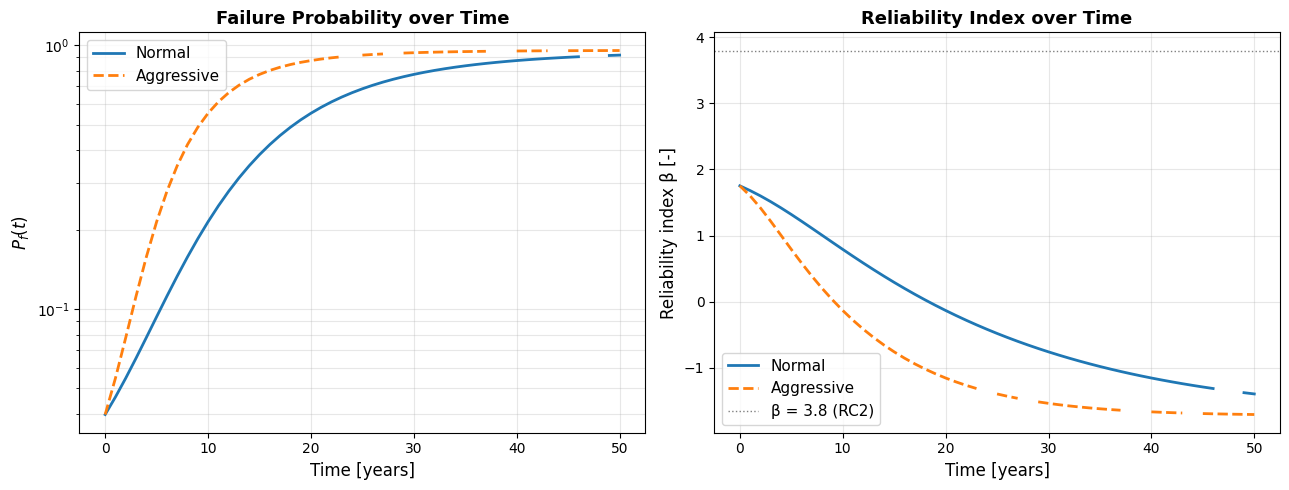

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Pf vs time
ax = axes[0]
for name in models:
    ax.plot(times, results[name]["pf"],
            color=model_colors[name], linestyle=model_styles[name],
            linewidth=2, label=name)
ax.set_xlabel("Time [years]", fontsize=12)
ax.set_ylabel(r"$P_f(t)$", fontsize=12)
ax.set_title("Failure Probability over Time", fontweight="bold", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.3)

# Right: beta vs time
ax = axes[1]
for name in models:
    ax.plot(times, results[name]["beta"],
            color=model_colors[name], linestyle=model_styles[name],
            linewidth=2, label=name)
ax.axhline(3.8, color="grey", linestyle=":", linewidth=1, label="β = 3.8 (RC2)")
ax.set_xlabel("Time [years]", fontsize=12)
ax.set_ylabel("Reliability index β [-]", fontsize=12)
ax.set_title("Reliability Index over Time", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Interpretation

The $\beta(t)$ timeline shows how the two corrosion environments drive very different structural lifetimes for the canal wall:

- The **Normal** scenario (fresh-water canal) degrades gradually — $\beta$ stays above the RC2 target ($\beta$ = 3.8) for a longer period before entering the critical zone.
- The **Aggressive** scenario (brackish/saline canal) reaches the same $\beta$ level roughly **twice as fast**, consistent with the doubled $\lambda$.
- The horizontal reference line at $\beta$ = 3.8 makes it easy to read off the **remaining safe service life** for each environment.
- The gap between the two curves quantifies the **value of corrosion protection**: coating, cathodic protection, or material selection that shifts the wall from the aggressive to the normal regime extends the safe service life significantly. For canal walls, this translates directly into maintenance planning and waterway management decisions.

### Combined overview

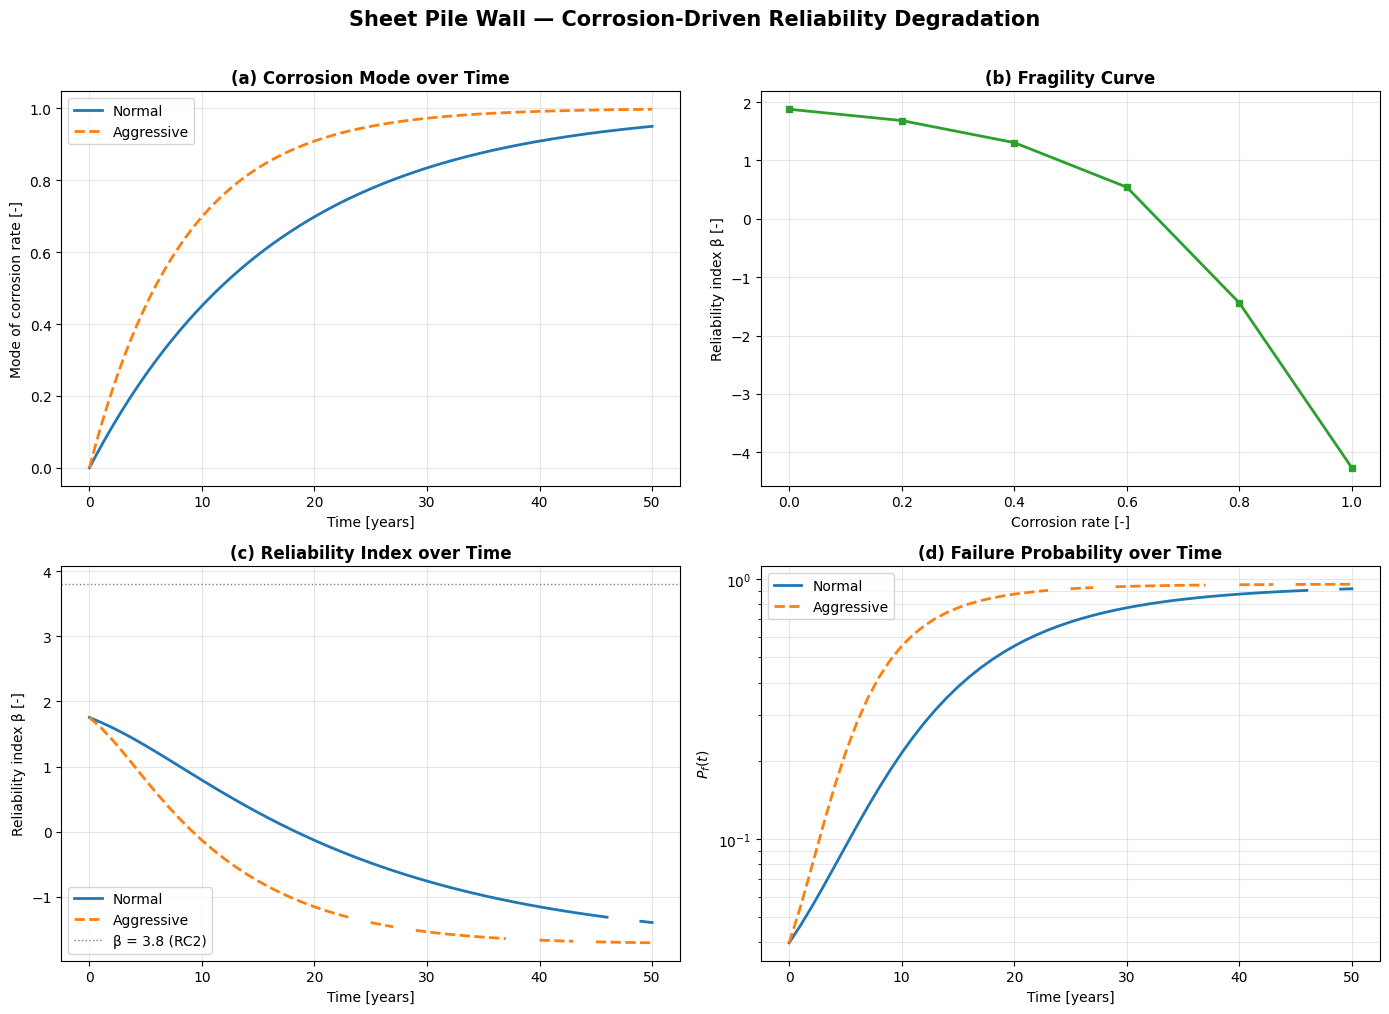

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) — Corrosion mode evolution
ax = axes[0, 0]
for name, lam in models.items():
    ax.plot(t_arr, 1 - np.exp(-lam * t_arr), linewidth=2,
            color=model_colors[name], linestyle=model_styles[name], label=name)
ax.set_xlabel("Time [years]")
ax.set_ylabel("Mode of corrosion rate [-]")
ax.set_title("(a) Corrosion Mode over Time", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# (0,1) — Fragility curve (β vs r)
ax = axes[0, 1]
ax.plot(corrosion_rates, fc_beta, "s-", color="tab:green", linewidth=2, markersize=5)
ax.set_xlabel("Corrosion rate [-]")
ax.set_ylabel("Reliability index β [-]")
ax.set_title("(b) Fragility Curve", fontweight="bold")
ax.grid(True, alpha=0.3)

# (1,0) — β(t) timeline
ax = axes[1, 0]
for name in models:
    ax.plot(times, results[name]["beta"], linewidth=2,
            color=model_colors[name], linestyle=model_styles[name], label=name)
ax.axhline(3.8, color="grey", linestyle=":", linewidth=1, label="β = 3.8 (RC2)")
ax.set_xlabel("Time [years]")
ax.set_ylabel("Reliability index β [-]")
ax.set_title("(c) Reliability Index over Time", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# (1,1) — Pf(t) timeline
ax = axes[1, 1]
for name in models:
    ax.plot(times, results[name]["pf"], linewidth=2,
            color=model_colors[name], linestyle=model_styles[name], label=name)
ax.set_xlabel("Time [years]")
ax.set_ylabel(r"$P_f(t)$")
ax.set_title("(d) Failure Probability over Time", fontweight="bold")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Sheet Pile Wall — Corrosion-Driven Reliability Degradation",
             fontweight="bold", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

### Results summary table

In [15]:
# Print every 5 years
step = 5
header_names = "  ".join(f"{'β ' + n:>12s}" for n in models)
header_pf    = "  ".join(f"{'Pf ' + n:>14s}" for n in models)
print(f"{'Time':>6}  {header_names}  {header_pf}")
print(f"{'[yr]':>6}  " + "  ".join(f"{'[-]':>12s}" for _ in models) +
      "  " + "  ".join(f"{'[-]':>14s}" for _ in models))
print("-" * (8 + 14 * len(models) + 16 * len(models)))

for i, t in enumerate(times):
    if t % step != 0:
        continue
    cols_b = "  ".join(f"{results[n]['beta'][i]:>12.3f}" for n in models)
    cols_p = "  ".join(f"{results[n]['pf'][i]:>14.4e}" for n in models)
    print(f"{t:>6.0f}  {cols_b}  {cols_p}")

  Time      β Normal  β Aggressive       Pf Normal   Pf Aggressive
  [yr]           [-]           [-]             [-]             [-]
--------------------------------------------------------------------
     0         1.753         1.753      3.9808e-02      3.9808e-02
     5         1.320         0.791      9.3494e-02      2.1436e-01
    10         0.791        -0.133      2.1436e-01      5.5303e-01
    15         0.292        -0.760      3.8519e-01      7.7628e-01
    20        -0.133        -1.155      5.5303e-01      8.7600e-01
    25        -0.481        -1.396      6.8467e-01      9.1870e-01
    30        -0.760        -1.539      7.7628e-01      9.3808e-01
    35        -0.981        -1.621      8.3672e-01      9.4749e-01
    40        -1.155        -1.667      8.7600e-01      9.5229e-01
    45        -1.291        -1.693      9.0167e-01      9.5482e-01
    50        -1.396        -1.708      9.1870e-01      9.5617e-01


In [15]:
# Print every 5 years
step = 5
header_names = "  ".join(f"{'β ' + n:>12s}" for n in models)
header_pf    = "  ".join(f"{'Pf ' + n:>14s}" for n in models)
print(f"{'Time':>6}  {header_names}  {header_pf}")
print(f"{'[yr]':>6}  " + "  ".join(f"{'[-]':>12s}" for _ in models) +
      "  " + "  ".join(f"{'[-]':>14s}" for _ in models))
print("-" * (8 + 14 * len(models) + 16 * len(models)))

for i, t in enumerate(times):
    if t % step != 0:
        continue
    cols_b = "  ".join(f"{results[n]['beta'][i]:>12.3f}" for n in models)
    cols_p = "  ".join(f"{results[n]['pf'][i]:>14.4e}" for n in models)
    print(f"{t:>6.0f}  {cols_b}  {cols_p}")

  Time      β Normal  β Aggressive       Pf Normal   Pf Aggressive
  [yr]           [-]           [-]             [-]             [-]
--------------------------------------------------------------------
     0           nan           nan             nan             nan
     5           nan           nan             nan             nan
    10           nan           nan             nan             nan
    15           nan           nan             nan             nan
    20           nan           nan             nan             nan
    25           nan           nan             nan             nan
    30           nan           nan             nan             nan
    35           nan           nan             nan             nan
    40           nan           nan             nan             nan
    45           nan           nan             nan             nan
    50           nan           nan             nan             nan
